<a href="https://colab.research.google.com/github/iam7mza/EventClassification/blob/main/FeatureSelection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# # Downloading the dataset from GitHub (uncomment when running on Colab)
# !git clone "https://github.com/iam7mza/EventClassification.git"
# !mv EventClassification/* ./
# !rm -rf EventClassification
# !rm -rf sample_data



############# !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! no touch zone !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! #############
#importing data

import loader
import numpy as np
import pandas as pd

filepath = "EW" 
df = loader.load(filepath);
loader.clean(df); #to clean the data

df = df[df['numeric_target'] != -1]  #dropping all the unknown events

# Check unique event types and their corresponding targets
event_target_mapping = df[['event_type', 'numeric_target']].drop_duplicates().sort_values('numeric_target')
print("Event type to target mapping:")
print(event_target_mapping)

print(f'columns = {df.columns}')

############################################################
#########extracing features and values from lists###########
#############################################################`

# the chosen ones
# TheChosenOnes = ['trigE', 'trigM', 'trigP', 'lep_n','lep_pt', 'lep_eta', 'lep_phi',
#        'lep_E', 'lep_z0', 'lep_charge', 'lep_type', 'lep_isTightID',
#        'lep_ptcone30', 'lep_etcone20', 'lep_trackd0pvunbiased',
#        'lep_tracksigd0pvunbiased', 'met_et', 'met_phi', 'jet_n', 'jet_pt',
#        'jet_eta', 'jet_phi', 'jet_E', 'jet_jvt','jet_MV2c10', 'photon_n','photon_pt', 'photon_eta', 'photon_phi',
#        'photon_E', 'photon_isTightID', 'photon_ptcone30', 'photon_etcone20',
#        'photon_convType', 'largeRjet_n', 'largeRjet_pt', 'largeRjet_eta',
#        'largeRjet_phi', 'largeRjet_E', 'largeRjet_m','largeRjet_D2', 'largeRjet_tau32', 'tau_n', 'tau_pt', 'tau_eta',
#        'tau_phi', 'tau_E', 'tau_charge', 'tau_isTightID', 'tau_nTracks', 'tau_BDTid', 'ditau_m', 'lep_pt_syst',
#        'met_et_syst', 'jet_pt_syst', 'photon_pt_syst', 'largeRjet_pt_syst',
#        'tau_pt_syst']


TheChosenOnes = ['trigE', 'trigM', 'trigP', 'lep_n','lep_pt', 'lep_eta', 'lep_phi',
       'lep_E', 'lep_z0', 'lep_charge', 'lep_type', 'lep_isTightID',
       'lep_ptcone30', 'lep_etcone20', 'lep_trackd0pvunbiased',
       'lep_tracksigd0pvunbiased', 'met_et', 'met_phi', 'jet_n', 'jet_pt',
       'jet_eta', 'jet_phi', 'jet_E', 'jet_jvt','jet_MV2c10', 'photon_n','photon_pt', 'photon_eta', 'photon_phi',
       'photon_E', 'photon_isTightID', 'photon_ptcone30', 'photon_etcone20',
       'photon_convType', 'largeRjet_n', 'largeRjet_pt', 'largeRjet_eta',
       'largeRjet_phi', 'largeRjet_E', 'largeRjet_m','largeRjet_D2', 'largeRjet_tau32', 'tau_n', 'tau_pt', 'tau_eta',
       'tau_phi', 'tau_E', 'tau_charge', 'tau_isTightID', 'tau_nTracks', 'tau_BDTid', 'ditau_m']

#df[TheChosenOnes]

#extracting the features for lists (only first two elements)

#TODO: Turn into a function and make the number of cols an arg
# Separate list and scalar columns

def extract_list_features(df, list_cols, scalar_cols, n_elements=2):
    """
    Extract features from list columns with configurable number of elements.

    Parameters:
    df: DataFrame containing the data
    list_cols: List of column names that contain lists
    scalar_cols: List of column names that contain scalar values
    n_elements: Number of elements to extract from each list (max 5)

    Returns:
    DataFrame with extracted features
    """
    # Ensure n_elements is within valid range
    n_elements = min(max(n_elements, 1), 5)

    # Element names for readability
    element_names = ['first', 'second', 'third', 'fourth', 'fifth']

    extracted_data = {}

    # Add scalar columns
    for col in scalar_cols:
        extracted_data[col] = df[col]

    # Add list-derived columns
    for col in list_cols:
        for i in range(n_elements):
            col_name = f'{col}_{element_names[i]}'
            extracted_data[col_name] = df[col].apply(
                lambda x: x[i] if len(x) > i else np.nan
            )

    return pd.DataFrame(extracted_data)

# Usage with configurable number of elements
n_elements = 5  # Change this to extract 1-5 elements from each list

# Separate list and scalar columns
list_cols = []
scalar_cols = []

for col in TheChosenOnes:
    if col in df.columns:
        if isinstance(df[col].iloc[0], list):  # Use iloc[0] instead of [0]
            list_cols.append(col)
        else:
            scalar_cols.append(col)

print(f"List columns: {len(list_cols)}")
print(f"Scalar columns: {len(scalar_cols)}")
print(f"Extracting {n_elements} elements from each list column")

# Extract features with specified number of elements
df_extracted = extract_list_features(df, list_cols, scalar_cols, n_elements)

print(f"Shape after feature extraction: {df_extracted.shape}")

# Drop columns that are all zeros or nan
columns_to_drop = []
for col in df_extracted.columns:
    if df_extracted[col].isna().all():  # nan check
        columns_to_drop.append(col)
        print(f"Column {col} is all NaN, will drop it.")
    elif (df_extracted[col] == 0).all():  # zero check
        columns_to_drop.append(col)
        print(f"Column {col} is all zeros, will drop it.")


# Drop all NaN columns at once
if columns_to_drop:
    df_extracted = df_extracted.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} NaN columns")

print(f"Final shape: {df_extracted.shape}")
df_extracted

################################################################
## remving zero heavy columns ##################################
################################################################

# First, let's see what columns with _first we have
first_cols = [col for col in df_extracted.columns if '_first' in col]
print("Columns with '_first':")
print(first_cols)

# Features to compute TOTAL (sum)
total_base_features = ['lep_pt', 'lep_E', 'lep_charge', 'lep_ptcone30', 'lep_etcone20',
                      'jet_pt', 'jet_E', 'largeRjet_pt', 'largeRjet_E', 'largeRjet_m']

# Features to compute MEAN (average)
mean_base_features = ['lep_eta', 'lep_phi', 'lep_z0', 'jet_eta', 'jet_phi',
                     'largeRjet_eta', 'largeRjet_phi', 'lep_pt_syst', 'jet_pt_syst',
                     'largeRjet_pt_syst']

element_indicators = ['_first', '_second', '_third', '_fourth', '_fifth']

print("\nCreating TOTAL columns:")
# Create total columns
for base_feature in total_base_features:
    feature_cols = []
    for indicator in element_indicators:
        col_name = f'{base_feature}{indicator}'
        if col_name in df_extracted.columns:
            feature_cols.append(col_name)

    if len(feature_cols) > 0:
        total_col_name = f'{base_feature}_total'
        df_extracted[total_col_name] = df_extracted[feature_cols].sum(axis=1)
        print(f"  {total_col_name} from {len(feature_cols)} columns: {feature_cols}")

print("\nCreating MEAN columns:")
# Create mean columns
for base_feature in mean_base_features:
    feature_cols = []
    for indicator in element_indicators:
        col_name = f'{base_feature}{indicator}'
        if col_name in df_extracted.columns:
            feature_cols.append(col_name)

    if len(feature_cols) > 0:
        mean_col_name = f'{base_feature}_mean'
        # Calculate mean excluding zeros to avoid bias from missing particles

        ##TODO: Im not sure if replacing 0 with NaN is the best way to calculate mean here
        df_extracted[mean_col_name] = df_extracted[feature_cols].replace(0, np.nan).mean(axis=1, skipna=True).fillna(0)
        print(f"  {mean_col_name} from {len(feature_cols)} columns: {feature_cols}")

print(f"\nShape after adding totals and means: {df_extracted.shape}")

# Show new columns created
new_total_cols = [col for col in df_extracted.columns if '_total' in col]
new_mean_cols = [col for col in df_extracted.columns if '_mean' in col]
print(f"Added {len(new_total_cols)} total columns and {len(new_mean_cols)} mean columns")
print(f"Total columns: {new_total_cols}")
print(f"Mean columns: {new_mean_cols}")


############################################################
########### dropping nan heavy rows ########################
############################################################
#TODO: create cols with total values (for pt, E, et, etc.) such that when some cols are dropped, the total still exists

percentlim = 0.1  # 10% limit
nan_fraction = df_extracted.isna().mean(axis=0)  # Fraction of NaN values per column
high_nan_cols = nan_fraction[nan_fraction > percentlim].index.tolist()
print(f'{len(high_nan_cols)} cols are more than {percentlim*100:.0f}% NaN out of {len(df_extracted.columns)}')
print("NaN fractions per column:")
for col, frac in zip(df_extracted.columns, nan_fraction):
    if frac > 0:  # Only show columns with some NaN values
        print(f"  {col}: {frac*100:.1f}%")

df_extracted = df_extracted.drop(high_nan_cols, axis=1)
print(f'Columns remaining after dropping high-NaN columns: {len(df_extracted.columns)}')

df_extracted

#Dropping nan rows (if they exist)

nan_counts = df_extracted.isna().sum()
columns_with_nan = nan_counts[nan_counts > 0]
print(f"Columns with NaN values ({len(columns_with_nan)} out of {len(nan_counts)}):")
if len(columns_with_nan) > 0:
    for col, count in columns_with_nan.items():
        print(f"  {col}: {count}")
else:
    print("No columns have NaN values! YIPPIEEE!!")

# FIXED: Drop the same rows from both features AND targets
print(f"Shape before dropping NaN rows: {df_extracted.shape}")
rows_before = len(df_extracted)

# Get mask for rows WITHOUT any NaN values
valid_rows_mask = ~df_extracted.isna().any(axis=1)

# Apply the same mask to BOTH dataframes
df_extracted = df_extracted[valid_rows_mask]
df = df[valid_rows_mask]  # Drop same rows from targets!

rows_after = len(df_extracted)
print(f"Shape after dropping NaN rows: {df_extracted.shape}")
print(f"Dropped {rows_before - rows_after} rows with NaN values")
print(f"Target dataframe shape: {df.shape}")

# Verify alignment
print(f"Features and targets are aligned: {len(df_extracted) == len(df)}")




Found 195 CSV files
Processing: EW/mc_305574.Gmumu_01_2000.exactly2lep_sample2000.csv
  -> Added 2000 events (event name: mc_305574.Gmumu_01_2000.exactly2lep)
Processing: EW/mc_364176.Wenu_PTV140_280_CVetoBVeto.exactly2lep_sample2000.csv
  -> Added 2000 events (event name: mc_364176.Wenu_PTV140_280_CVetoBVeto.exactly2lep)
Processing: EW/mc_392361.C1N2_WZ_700_400_2L2J_2L7.exactly2lep_sample2000.csv
  -> Added 2000 events (event name: mc_392361.C1N2_WZ_700_400_2L2J_2L7.exactly2lep)
Processing: EW/mc_364162.Wmunu_PTV140_280_CVetoBVeto.exactly2lep_sample2000.csv
  -> Added 2000 events (event name: mc_364162.Wmunu_PTV140_280_CVetoBVeto.exactly2lep)
Processing: EW/mc_364138.Ztautau_PTV280_500_CFilterBVeto.exactly2lep_sample2000.csv
  -> Added 2000 events (event name: mc_364138.Ztautau_PTV280_500_CFilterBVeto.exactly2lep)
Processing: EW/mc_364141.Ztautau_PTV1000_E_CMS.exactly2lep_sample2000.csv
  -> Added 2000 events (event name: mc_364141.Ztautau_PTV1000_E_CMS.exactly2lep)
Processing: EW/mc_

## CORR

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

print(len(df_extracted.columns))
corr = df_extracted.corr().abs()
# sns.heatmap(corr)
# plt.show()

# Select upper triangle of correlation matrix
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Find features with correlation greater than 0.7
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]
print('cols to drop:' + str(to_drop))
# Drop features 
df_extracted.drop(to_drop, axis=1, inplace=True)

corr2 = df_extracted.corr().abs()
print(len(df_extracted.columns))
# sns.heatmap(corr2)
# plt.show()

54
cols to drop:['trigM', 'lep_pt_first', 'lep_E_first', 'lep_E_second', 'lep_type_first', 'jet_pt_second', 'jet_E_first', 'jet_E_second', 'lep_pt_total', 'lep_E_total', 'lep_ptcone30_total', 'lep_etcone20_total', 'jet_pt_total', 'jet_E_total', 'lep_eta_mean', 'lep_z0_mean', 'jet_eta_mean']
37


## SCALING

In [3]:
from sklearn.preprocessing import QuantileTransformer

#TODO: Do not plot heatmap next time cause that shit takes forever
qt = QuantileTransformer(output_distribution='uniform', n_quantiles=1000) #TODO: try uniform distribution
X_scaled = qt.fit_transform(df_extracted)

# sns.pairplot(df_extracted.iloc[:,0:10])
# plt.show()
Xdf = pd.DataFrame(X_scaled, columns=df_extracted.columns)
# sns.pairplot(Xdf.iloc[:,0:10])
# plt.show()

## Splitting and Training

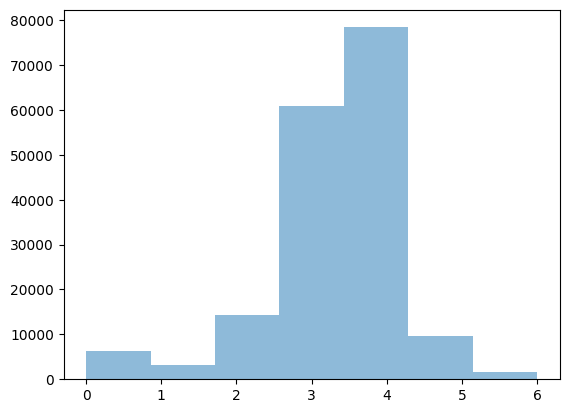

In [4]:
from sklearn.model_selection import train_test_split
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, df['numeric_target'], test_size=0.2, random_state=42, stratify=df['numeric_target'])

num_classes = len(df['numeric_target'].unique())
plt.hist(y_train, bins=num_classes, alpha=0.5, label='Train')
plt.show()

## SAFE LEVEL SMOTE

Setting this up was very funky, but it should work fine now.


NOTE: seems very useful but takes forever to run and sometimes it just gets stuck...  thus will be skipped for now

In [5]:
# from crucio import SLS
# from collections import Counter
# from tqdm import tqdm
# import time

# # Check class distribution before balancing
# print("Class distribution before balancing:")
# print(Counter(y_train))

# # Fix: Use the correct column names that match X_train
# remaining_columns = df_extracted.columns.tolist()

# # Create DataFrame with correct column names
# X_df = pd.DataFrame(X_train, columns=remaining_columns)
# X_df['y_train'] = y_train

# print(f"X_train shape: {X_train.shape}")
# print(f"df_extracted columns: {len(df_extracted.columns)}")
# print(f"X_df shape: {X_df.shape}")

# # Initialize SLS with timeout
# sls = SLS()

# # Balance the dataset with timeout and progress tracking
# print("Starting SLS balancing... (this may take a while)")
# start_time = time.time()
# timeout_seconds = 300  # 5 minutes timeout

# try:
#     # Create a progress bar
#     with tqdm(desc="SLS Progress", unit="iterations") as pbar:
#         X_balanced = sls.balance(X_df, 'y_train')
#         pbar.update(1)
    
#     print("SLS balancing successful!")
#     print(f"Balanced dataset shape: {X_balanced.shape}")
    
#     # Check class distribution after balancing
#     print("Class distribution after balancing:")
#     print(Counter(X_balanced['y_train']))
    
# except Exception as e:
#     elapsed_time = time.time() - start_time
#     print(f"SLS failed after {elapsed_time:.1f} seconds: {e}")
#     print("Falling back to regular SMOTE (much faster)...")
    
#     # Use regular SMOTE as fallback
#     from imblearn.over_sampling import SMOTE
    
#     with tqdm(desc="SMOTE Progress", total=100) as pbar:
#         smote = SMOTE(random_state=42)
#         pbar.update(25)
        
#         X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
#         pbar.update(50)
        
#         # Create balanced DataFrame
#         X_balanced = pd.DataFrame(X_train_balanced, columns=remaining_columns)
#         X_balanced['y_train'] = y_train_balanced
#         pbar.update(25)
    
#     print("SMOTE balancing successful!")
#     print(f"Balanced dataset shape: {X_balanced.shape}")
#     print("Class distribution after balancing:")
#     print(Counter(X_balanced['y_train']))

## Class Weights 

helps fix the imbalance in the data


MADE EVERYTHING WORSE

In [6]:
# # class weighting
# from sklearn.utils.class_weight import compute_class_weight
# class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
# class_weight_dict = dict(zip(np.unique(y_train), class_weights))
# print("Class weights:", class_weight_dict)

## Simple Dense Model

2025-07-10 00:14:02.395284: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-10 00:14:02.607071: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-10 00:14:02.794002: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1752099242.938242   11804 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1752099242.978098   11804 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1752099243.300002   11804 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

Epoch 1/50


2025-07-10 00:14:07.576842: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


4360/4360 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.6471 - loss: 1.0450 - val_accuracy: 0.7207 - val_loss: 0.8218
Epoch 2/50
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7082 - loss: 0.8601 - val_accuracy: 0.7270 - val_loss: 0.7957
Epoch 3/50
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7180 - loss: 0.8279 - val_accuracy: 0.7342 - val_loss: 0.7678
Epoch 4/50
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7235 - loss: 0.8064 - val_accuracy: 0.7352 - val_loss: 0.7663
Epoch 5/50
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7285 - loss: 0.7920 - val_accuracy: 0.7413 - val_loss: 0.7495
Epoch 6/50
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7326 - loss: 0.7848 - val_accuracy: 0.7401 - val_loss: 0.7530
Epoch 7/50
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - accuracy: 0.7324 - loss: 0.7803 - val_accuracy: 0.7427 - val_loss: 0.7374
Epoch 8/50
4360/4360 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step - accuracy: 0.7344 - loss: 0.7751 - val

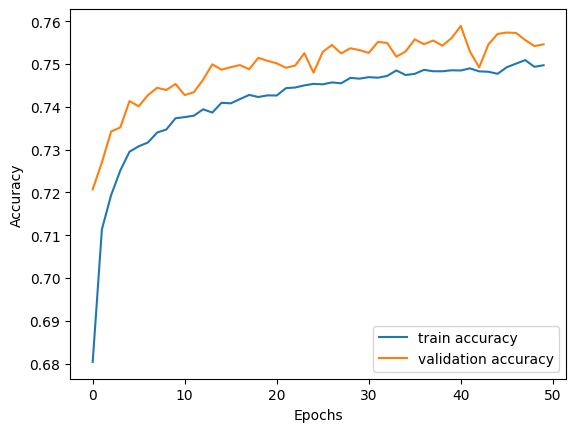

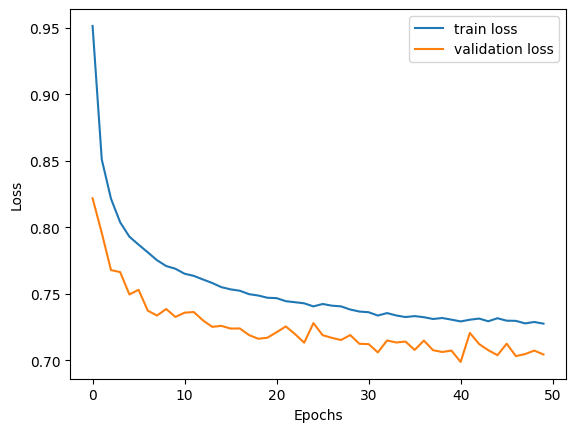

1363/1363 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


NameError: name 'cm' is not defined

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input 
from tensorflow.keras.optimizers import Adam

# Define the model
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.25))
# model.add(Dense(512, activation='relu'))
# model.add(Dropout(0.2))
# model.add(Dense(256, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.25))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)


###############
#plotting#

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# Plot absolute counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=event_target_mapping['event_type'])
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix (Counts)')
plt.show()

# Plot percentages
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_percent, annot=True, fmt=".1f", cmap='Blues', 
            xticklabels=event_target_mapping['event_type'], 
            yticklabels=event_target_mapping['event_type'])
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (%)')
plt.show()

## BDT

[0]	validation_0-mlogloss:1.78053	validation_1-mlogloss:1.78100
[1]	validation_0-mlogloss:1.64904	validation_1-mlogloss:1.65028
[2]	validation_0-mlogloss:1.54249	validation_1-mlogloss:1.54408
[3]	validation_0-mlogloss:1.45292	validation_1-mlogloss:1.45521
[4]	validation_0-mlogloss:1.37549	validation_1-mlogloss:1.37846
[5]	validation_0-mlogloss:1.30935	validation_1-mlogloss:1.31283
[6]	validation_0-mlogloss:1.25266	validation_1-mlogloss:1.25672
[7]	validation_0-mlogloss:1.20337	validation_1-mlogloss:1.20773
[8]	validation_0-mlogloss:1.15741	validation_1-mlogloss:1.16227
[9]	validation_0-mlogloss:1.11776	validation_1-mlogloss:1.12322
[10]	validation_0-mlogloss:1.08272	validation_1-mlogloss:1.08864
[11]	validation_0-mlogloss:1.04892	validation_1-mlogloss:1.05534
[12]	validation_0-mlogloss:1.01922	validation_1-mlogloss:1.02605
[13]	validation_0-mlogloss:0.99332	validation_1-mlogloss:1.00068
[14]	validation_0-mlogloss:0.96943	validation_1-mlogloss:0.97726
[15]	validation_0-mlogloss:0.94759	

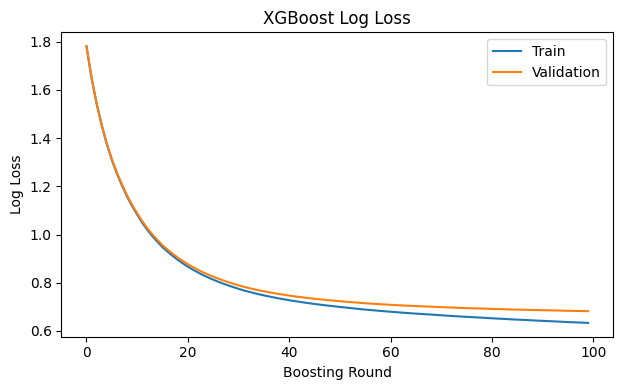

In [8]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report


model = xgb.XGBClassifier(
    objective='multi:softprob',  # Multi-class classification
    n_estimators=100,           # Number of boosting rounds (like epochs)
    max_depth=6,               # Maximum tree depth
    learning_rate=0.1,         # Learning rate (like optimizer step size)
    subsample=0.8,             # Fraction of samples used for training each tree
    colsample_bytree=0.8,      # Fraction of features used for each tree
    random_state=123,          # For reproducibility
    eval_metric='mlogloss',    # Multi-class log loss
    early_stopping_rounds=50,   # Stop if no improvement for 10 rounds
    verbosity=1
)

# Train the model (corrected parameters)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}")
print(classification_report(y_test, y_pred))

# Plot training history
results = model.evals_result()
epochs = len(results['validation_0']['mlogloss'])
x_axis = range(0, epochs)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(x_axis, results['validation_0']['mlogloss'], label='Train')
plt.plot(x_axis, results['validation_1']['mlogloss'], label='Validation')
plt.ylabel('Log Loss')
plt.xlabel('Boosting Round')
plt.title('XGBoost Log Loss')
plt.legend()

plt.tight_layout()
plt.show()